In [2]:
!pip install -q --upgrade "protobuf==6.31.1" "tensorflow-datasets" "importlib_resources"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [1]:
!pip install -q --upgrade tensorflow-datasets importlib_resources

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import google.protobuf

print("TensorFlow:", tf.__version__)
print("Protobuf:", google.protobuf.__version__)
print("TFDS:", getattr(tfds, "__version__", "unknown"))
print("TFDS load available:", hasattr(tfds, "load"))

/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TensorFlow: 2.20.0
Protobuf: 6.31.1
TFDS: 4.9.10
TFDS load available: True


In [2]:
(train_data, val_data, test_data), info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True
)

print("Training samples:", tf.data.experimental.cardinality(train_data).numpy())
print("Validation samples:", tf.data.experimental.cardinality(val_data).numpy())
print("Test samples:", tf.data.experimental.cardinality(test_data).numpy())
print("Number of classes:", info.features["label"].num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.2OWGQK_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.2OWGQK_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Training samples: 2944
Validation samples: 736
Test samples: 3669
Number of classes: 37


In [3]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

In [4]:
train_dataset = train_data.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_data.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_data.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(1)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(1)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(1)

print("Training, validation and test datasets prepared successfully.")

Training, validation and test datasets prepared successfully.


In [5]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Pixel range:", tf.reduce_min(images).numpy(), "to", tf.reduce_max(images).numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image dtype: <dtype: 'float32'>
Pixel range: -1.0 to 1.0


In [10]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully.")
print("Number of layers:", len(base_model.layers))

MobileNetV2 loaded successfully.
Number of layers: 154


In [11]:
base_model.trainable = False

print("MobileNetV2 base model loaded.")
print("Base model trainable:", base_model.trainable)
print("Number of layers:", len(base_model.layers))

MobileNetV2 base model loaded.
Base model trainable: False
Number of layers: 154


In [9]:
IMG_SIZE = (224, 224)
NUM_CLASSES = 37
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001

print("Image Size:", IMG_SIZE)
print("Number of Classes:", NUM_CLASSES)
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning Rate:", LEARNING_RATE)

Image Size: (224, 224)
Number of Classes: 37
Batch Size: 16
Epochs: 10
Learning Rate: 0.001


In [12]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.initializers import (
    Zeros,
    RandomNormal,
    GlorotUniform,
    HeNormal
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [14]:
initialization_methods = {
    "Zero": Zeros(),
    "Random": RandomNormal(mean=0.0, stddev=0.05, seed=42),
    "Xavier/Glorot": GlorotUniform(seed=42),
    "He": HeNormal(seed=42)
}

print("Initialization methods:")
for name in initialization_methods:
    print("-", name)

Initialization methods:
- Zero
- Random
- Xavier/Glorot
- He


In [15]:
def create_model(initializer):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained MobileNetV2
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            kernel_initializer=initializer,
            bias_initializer="zeros"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

print("Model creation function ready.")

Model creation function ready.


In [16]:
EPOCHS = 5

histories = {}

for name, initializer in initialization_methods.items():

    print("\n" + "=" * 60)
    print("Training with:", name)
    print("=" * 60)

    model = create_model(initializer)

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    # Save only numerical values, NOT the Keras History object
    histories[name] = {
        "loss": list(history.history["loss"]),
        "accuracy": list(history.history["accuracy"]),
        "val_loss": list(history.history["val_loss"]),
        "val_accuracy": list(history.history["val_accuracy"])
    }

    # Free memory before the next model
    del history
    del model
    gc.collect()

    print(name, "completed successfully.")

print("\nAll four initialization experiments completed.")


Training with: Zero
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.8128 - loss: 0.9025 - val_accuracy: 0.9035 - val_loss: 0.3926
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9514 - loss: 0.2177 - val_accuracy: 0.9049 - val_loss: 0.3298
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9803 - loss: 0.1249 - val_accuracy: 0.9158 - val_loss: 0.2873
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9888 - loss: 0.0835 - val_accuracy: 0.9144 - val_loss: 0.2818
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.9973 - loss: 0.0568 - val_accuracy: 0.9062 - val_loss: 0.2645
Zero completed successfully.

Training with: Random
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 87ms/step - accuracy: 0.7171 - loss: 1.1225 - val_accuracy: 0.8750 - val_loss: 0.4386
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9310 - loss: 0.2589 - val_accuracy: 0.8886 - val_loss: 0.3643
Epoch 3/5
184/184 ━━━━━━

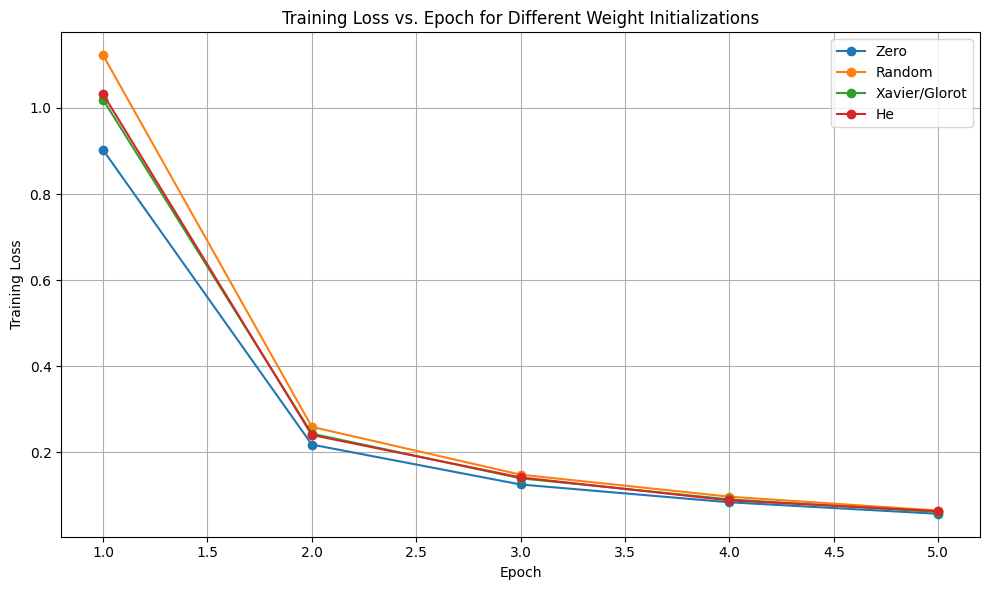

In [17]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        range(1, EPOCHS + 1),
        history["loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs. Epoch for Different Weight Initializations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

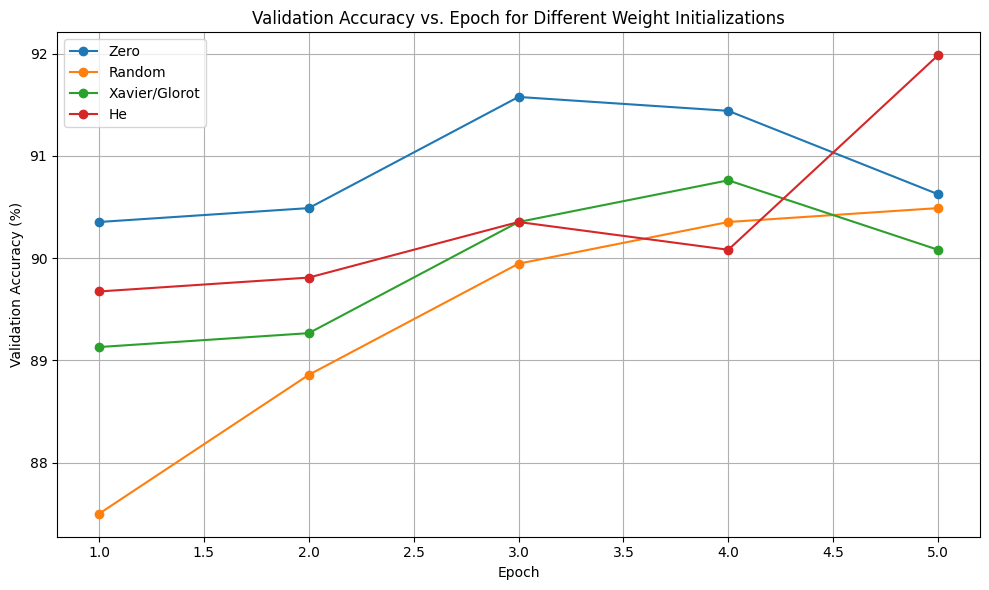

In [18]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs. Epoch for Different Weight Initializations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
print("\nWeight Initialization Comparison")
print("=" * 90)

results = []

for name, history in histories.items():

    train_loss = history["loss"]
    val_accuracy = history["val_accuracy"]

    final_loss = train_loss[-1]
    best_val_accuracy = max(val_accuracy) * 100
    best_epoch = np.argmax(val_accuracy) + 1

    # Improvement in validation accuracy from first to last epoch
    val_acc_improvement = (
        val_accuracy[-1] - val_accuracy[0]
    ) * 100

    results.append([
        name,
        final_loss,
        best_val_accuracy,
        best_epoch,
        val_acc_improvement
    ])

    print(
        f"{name:15s} | "
        f"Final Loss: {final_loss:.4f} | "
        f"Best Val Accuracy: {best_val_accuracy:.2f}% | "
        f"Best Epoch: {best_epoch} | "
        f"Val Acc Improvement: {val_acc_improvement:.2f}%"
    )


Weight Initialization Comparison
Zero            | Final Loss: 0.0568 | Best Val Accuracy: 91.58% | Best Epoch: 3 | Val Acc Improvement: 0.27%
Random          | Final Loss: 0.0642 | Best Val Accuracy: 90.49% | Best Epoch: 5 | Val Acc Improvement: 2.99%
Xavier/Glorot   | Final Loss: 0.0610 | Best Val Accuracy: 90.76% | Best Epoch: 4 | Val Acc Improvement: 0.95%
He              | Final Loss: 0.0631 | Best Val Accuracy: 91.98% | Best Epoch: 5 | Val Acc Improvement: 2.31%


In [20]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Initialization",
        "Final Training Loss",
        "Best Validation Accuracy (%)",
        "Best Epoch",
        "Validation Accuracy Improvement (%)"
    ]
)

results_df

,Initialization,Final Training Loss,Best Validation Accuracy (%),Best Epoch,Validation Accuracy Improvement (%)
0,Zero,0.056769,91.576087,3,0.271738
1,Random,0.064154,90.489131,5,2.989131
2,Xavier/Glorot,0.060967,90.760869,4,0.951082
3,He,0.063061,91.983694,5,2.309781


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import gc

def create_regularization_model(method):

    # Create a fresh MobileNetV2 for each experiment
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False

    model_layers = [
        base_model,
        layers.GlobalAveragePooling2D()
    ]

    # Add the required regularization method
    if method == "No Regularization":

        model_layers.append(
            layers.Dense(
                NUM_CLASSES,
                activation="softmax"
            )
        )

    elif method == "L2 Regularization":

        model_layers.append(
            layers.Dense(
                NUM_CLASSES,
                activation="softmax",
                kernel_regularizer=regularizers.l2(0.001)
            )
        )

    elif method == "Dropout":

        model_layers.extend([
            layers.Dropout(0.5),
            layers.Dense(
                NUM_CLASSES,
                activation="softmax"
            )
        ])

    elif method == "Batch Normalization":

        model_layers.extend([
            layers.BatchNormalization(),
            layers.Dense(
                NUM_CLASSES,
                activation="softmax"
            )
        ])

    model = models.Sequential(model_layers)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Regularization model function ready.")

Regularization model function ready.


In [22]:
regularization_methods = [
    "No Regularization",
    "L2 Regularization",
    "Dropout",
    "Batch Normalization"
]

print("Methods to be compared:")
for method in regularization_methods:
    print("-", method)

Methods to be compared:
- No Regularization
- L2 Regularization
- Dropout
- Batch Normalization


In [23]:
EPOCHS = 5

regularization_histories = {}

for method in regularization_methods:

    print("\n" + "=" * 60)
    print("Training:", method)
    print("=" * 60)

    model = create_regularization_model(method)

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    # Save only numerical values
    regularization_histories[method] = {
        "loss": list(history.history["loss"]),
        "accuracy": list(history.history["accuracy"]),
        "val_loss": list(history.history["val_loss"]),
        "val_accuracy": list(history.history["val_accuracy"])
    }

    # Free RAM before next model
    del history
    del model
    gc.collect()

    print(method, "completed successfully.")

print("\nAll regularization experiments completed.")


Training: No Regularization
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 92ms/step - accuracy: 0.7571 - loss: 0.9852 - val_accuracy: 0.8981 - val_loss: 0.4083
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.9429 - loss: 0.2336 - val_accuracy: 0.9049 - val_loss: 0.3334
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9718 - loss: 0.1359 - val_accuracy: 0.9035 - val_loss: 0.3070
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9878 - loss: 0.0888 - val_accuracy: 0.9062 - val_loss: 0.2910
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9956 - loss: 0.0603 - val_accuracy: 0.9117 - val_loss: 0.2973
No Regularization completed successfully.

Training: L2 Regularization
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 93ms/step - accuracy: 0.7412 - loss: 1.1193 - val_accuracy: 0.8859 - val_loss: 0.5339
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9385 - loss: 0.3569 - val_accuracy: 0.8995 - val_loss: 0.45

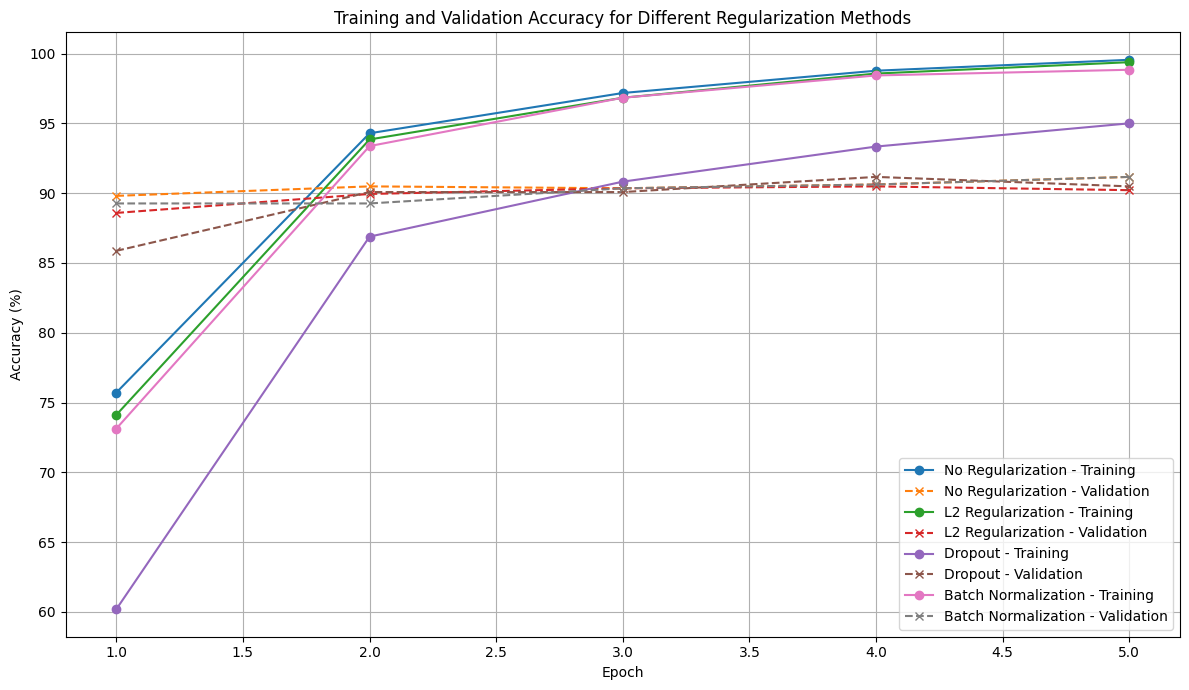

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

for method, history in regularization_histories.items():

    epochs = range(1, EPOCHS + 1)

    plt.plot(
        epochs,
        [x * 100 for x in history["accuracy"]],
        marker="o",
        label=f"{method} - Training"
    )

    plt.plot(
        epochs,
        [x * 100 for x in history["val_accuracy"]],
        marker="x",
        linestyle="--",
        label=f"{method} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy for Different Regularization Methods")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

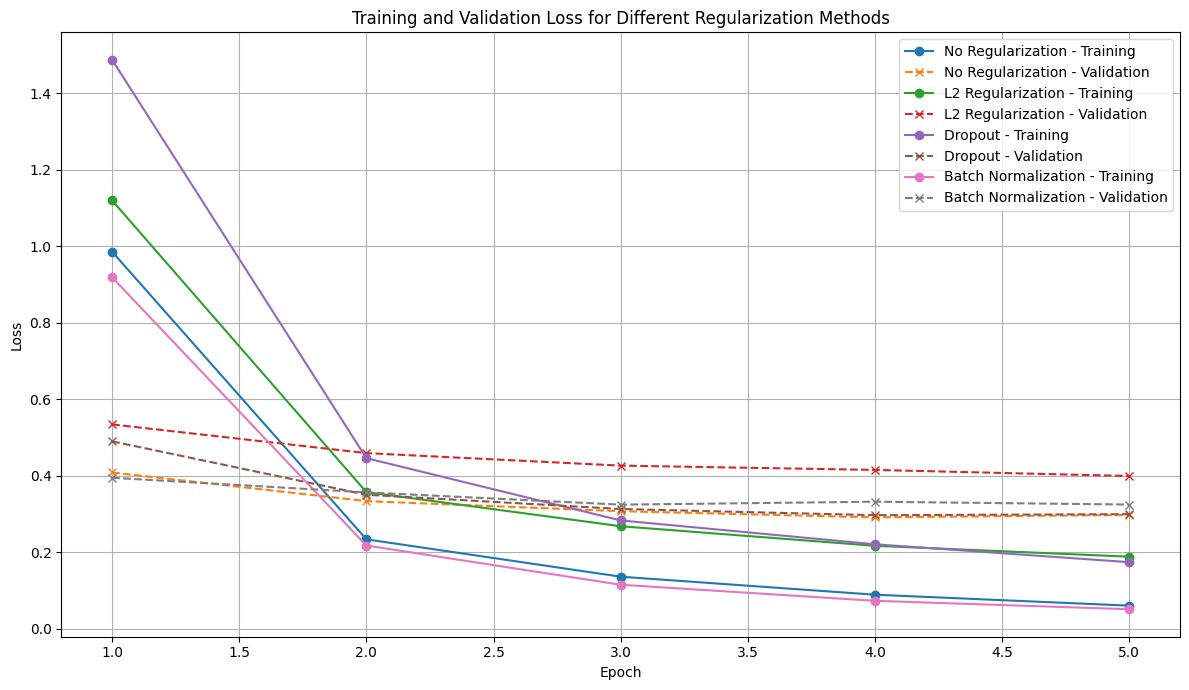

In [25]:
plt.figure(figsize=(12, 7))

for method, history in regularization_histories.items():

    epochs = range(1, EPOCHS + 1)

    plt.plot(
        epochs,
        history["loss"],
        marker="o",
        label=f"{method} - Training"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="x",
        linestyle="--",
        label=f"{method} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss for Different Regularization Methods")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
print("\nRegularization Comparison")
print("=" * 100)

regularization_results = []

for method, history in regularization_histories.items():

    final_train_acc = history["accuracy"][-1] * 100
    final_val_acc = history["val_accuracy"][-1] * 100

    generalization_gap = final_train_acc - final_val_acc

    best_val_acc = max(history["val_accuracy"]) * 100
    best_epoch = np.argmax(history["val_accuracy"]) + 1

    final_train_loss = history["loss"][-1]
    final_val_loss = history["val_loss"][-1]

    regularization_results.append([
        method,
        final_train_acc,
        final_val_acc,
        generalization_gap,
        best_val_acc,
        best_epoch,
        final_train_loss,
        final_val_loss
    ])

    print(
        f"{method:22s} | "
        f"Train Acc: {final_train_acc:6.2f}% | "
        f"Val Acc: {final_val_acc:6.2f}% | "
        f"Gap: {generalization_gap:6.2f}% | "
        f"Best Val: {best_val_acc:6.2f}%"
    )


Regularization Comparison
No Regularization      | Train Acc:  99.56% | Val Acc:  91.17% | Gap:   8.39% | Best Val:  91.17%
L2 Regularization      | Train Acc:  99.39% | Val Acc:  90.22% | Gap:   9.17% | Best Val:  90.49%
Dropout                | Train Acc:  95.01% | Val Acc:  90.49% | Gap:   4.52% | Best Val:  91.17%
Batch Normalization    | Train Acc:  98.85% | Val Acc:  91.17% | Gap:   7.68% | Best Val:  91.17%


In [27]:
import pandas as pd

regularization_df = pd.DataFrame(
    regularization_results,
    columns=[
        "Method",
        "Final Training Accuracy (%)",
        "Final Validation Accuracy (%)",
        "Generalization Gap (%)",
        "Best Validation Accuracy (%)",
        "Best Epoch",
        "Final Training Loss",
        "Final Validation Loss"
    ]
)

regularization_df

,Method,Final Training Accuracy (%),Final Validation Accuracy (%),Generalization Gap (%),Best Validation Accuracy (%),Best Epoch,Final Training Loss,Final Validation Loss
0,No Regularization,99.558425,91.168481,8.389944,91.168481,5,0.060255,0.297296
1,L2 Regularization,99.388587,90.217394,9.171194,90.489131,4,0.188222,0.399089
2,Dropout,95.006794,90.489131,4.517663,91.168481,4,0.173856,0.299376
3,Batch Normalization,98.845106,91.168481,7.676625,91.168481,5,0.050831,0.324522


In [28]:
def create_bn_model(use_bn):

    # Fresh MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained base
    base_model.trainable = False

    model_layers = [
        base_model,
        layers.GlobalAveragePooling2D()
    ]

    if use_bn:
        model_layers.append(
            layers.BatchNormalization()
        )

    model_layers.append(
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )

    model = models.Sequential(model_layers)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Batch Normalization model function ready.")

Batch Normalization model function ready.


In [29]:
EPOCHS = 5

bn_histories = {}

for name, use_bn in [
    ("Without BN", False),
    ("With BN", True)
]:

    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    model = create_bn_model(use_bn)

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    # Store only numerical history
    bn_histories[name] = {
        "val_accuracy": list(history.history["val_accuracy"]),
        "accuracy": list(history.history["accuracy"]),
        "loss": list(history.history["loss"]),
        "val_loss": list(history.history["val_loss"])
    }

    # Free RAM
    del history
    del model
    gc.collect()

    print(name, "completed successfully.")

print("\nBoth BN experiments completed.")


Training: Without BN
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 108ms/step - accuracy: 0.7561 - loss: 0.9987 - val_accuracy: 0.9022 - val_loss: 0.3994
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9440 - loss: 0.2327 - val_accuracy: 0.8981 - val_loss: 0.3314
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.9715 - loss: 0.1373 - val_accuracy: 0.8954 - val_loss: 0.3086
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9885 - loss: 0.0889 - val_accuracy: 0.8899 - val_loss: 0.2995
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.9963 - loss: 0.0616 - val_accuracy: 0.9090 - val_loss: 0.2786
Without BN completed successfully.

Training: With BN
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 34s 112ms/step - accuracy: 0.7395 - loss: 0.9093 - val_accuracy: 0.8614 - val_loss: 0.4356
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9331 - loss: 0.2160 - val_accuracy: 0.8899 - val_loss: 0.3465
Epoch 3/5
184/184 ━

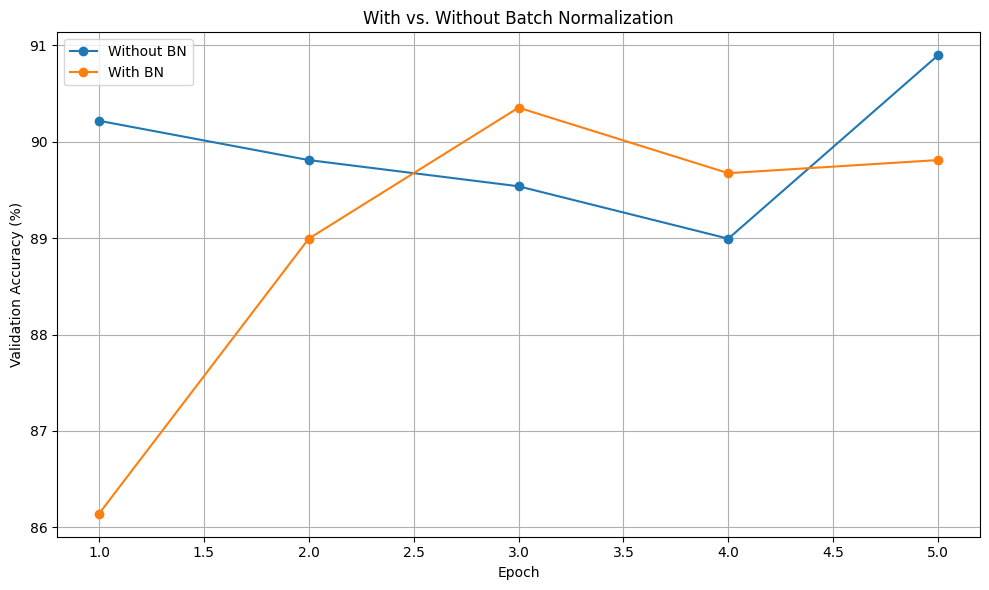

In [30]:
plt.figure(figsize=(10, 6))

for name, history in bn_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs. Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
print("\nBatch Normalization Comparison")
print("=" * 70)

for name, history in bn_histories.items():

    best_val_accuracy = max(history["val_accuracy"]) * 100
    best_epoch = np.argmax(history["val_accuracy"]) + 1

    print(
        f"{name:12s} | "
        f"Best Validation Accuracy: {best_val_accuracy:.2f}% | "
        f"Best Epoch: {best_epoch}"
    )


Batch Normalization Comparison
Without BN   | Best Validation Accuracy: 90.90% | Best Epoch: 5
With BN      | Best Validation Accuracy: 90.35% | Best Epoch: 3


In [32]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(
        learning_rate=LEARNING_RATE
    ),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=0.9
    ),

    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=LEARNING_RATE
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )
}

print("Optimizers:")
for name in optimizers:
    print("-", name)

Optimizers:
- SGD
- Momentum
- RMSProp
- Adam


In [33]:
def create_optimizer_model(optimizer):

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze ImageNet-pretrained layers
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Optimizer model function ready.")

Optimizer model function ready.


In [34]:
import time
import gc

EPOCHS = 5

optimizer_histories = {}
optimizer_times = {}

for name, optimizer in optimizers.items():

    print("\n" + "=" * 70)
    print("Training with:", name)
    print("=" * 70)

    model = create_optimizer_model(optimizer)

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        verbose=1
    )

    end_time = time.time()

    # Save only numerical history
    optimizer_histories[name] = {
        "loss": list(history.history["loss"]),
        "accuracy": list(history.history["accuracy"]),
        "val_loss": list(history.history["val_loss"]),
        "val_accuracy": list(history.history["val_accuracy"])
    }

    # Store training time
    optimizer_times[name] = end_time - start_time

    print(
        f"{name} training time: "
        f"{optimizer_times[name]:.2f} seconds"
    )

    # Free RAM
    del history
    del model
    gc.collect()

print("\nAll optimizer experiments completed.")


Training with: SGD
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 87ms/step - accuracy: 0.0693 - loss: 3.5961 - val_accuracy: 0.1236 - val_loss: 3.2793
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.2086 - loss: 3.0335 - val_accuracy: 0.3111 - val_loss: 2.7973
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.4073 - loss: 2.5776 - val_accuracy: 0.5027 - val_loss: 2.3953
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.5771 - loss: 2.1975 - val_accuracy: 0.6345 - val_loss: 2.0591
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.6780 - loss: 1.8837 - val_accuracy: 0.7024 - val_loss: 1.7823
SGD training time: 91.26 seconds

Training with: Momentum
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.4952 - loss: 2.1681 - val_accuracy: 0.7976 - val_loss: 1.0855
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.8689 - loss: 0.7502 - val_accuracy: 0.8777 - val_loss: 0.6383
Epoch 3/5
184/184 ━

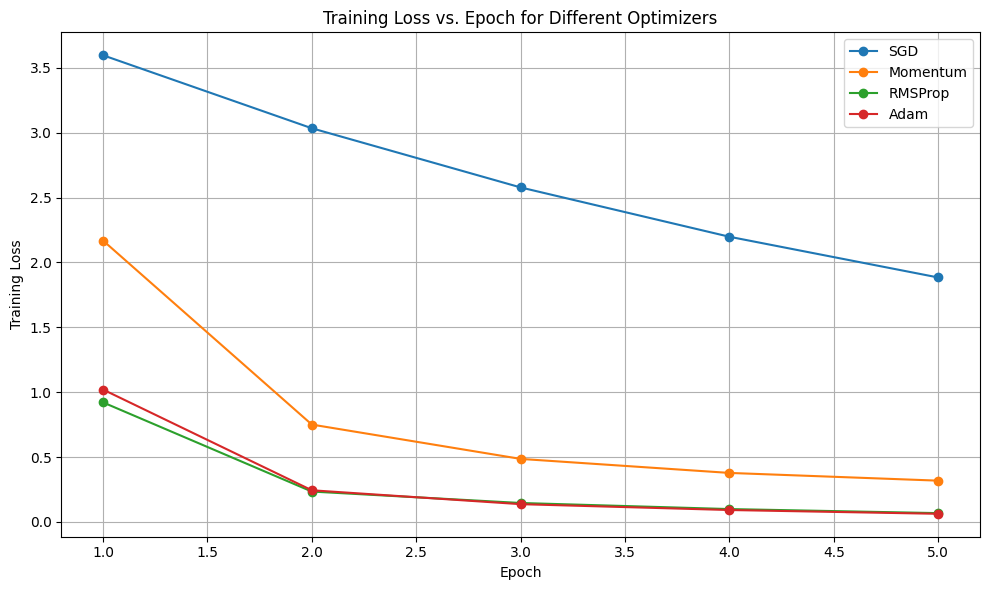

In [35]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        history["loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

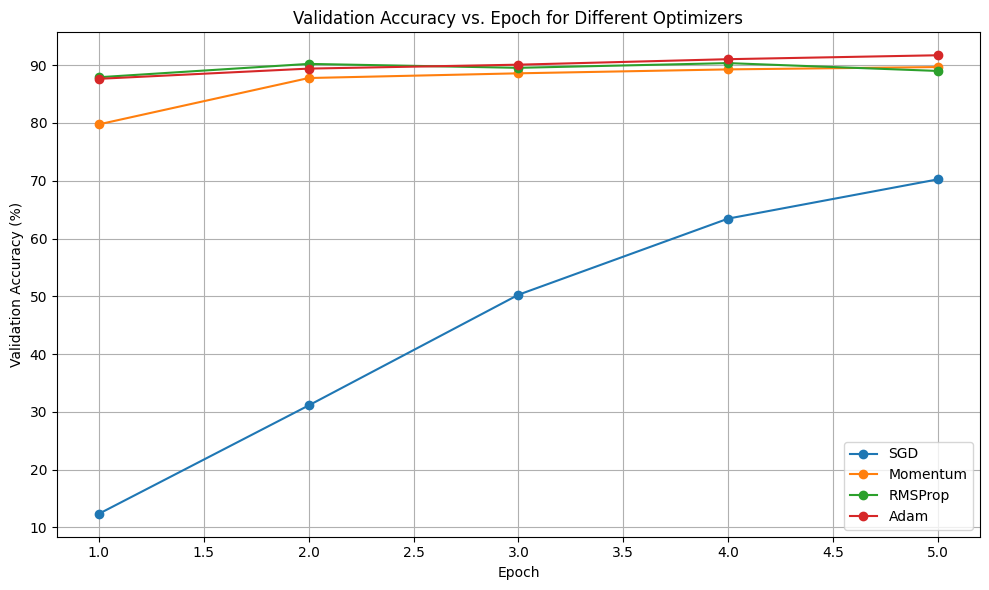

In [36]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        range(1, EPOCHS + 1),
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs. Epoch for Different Optimizers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
optimizer_results = []

for name, history in optimizer_histories.items():

    final_loss = history["loss"][-1]

    best_val_accuracy = max(history["val_accuracy"]) * 100

    epoch_to_converge = (
        np.argmax(history["val_accuracy"]) + 1
    )

    training_time = optimizer_times[name]

    optimizer_results.append([
        name,
        final_loss,
        best_val_accuracy,
        epoch_to_converge,
        training_time
    ])

optimizer_df = pd.DataFrame(
    optimizer_results,
    columns=[
        "Optimizer",
        "Final Loss",
        "Best Validation Accuracy (%)",
        "Epoch to Converge",
        "Time (seconds)"
    ]
)

optimizer_df

,Optimizer,Final Loss,Best Validation Accuracy (%),Epoch to Converge,Time (seconds)
0,SGD,1.883670,70.244563,5,91.255665
1,Momentum,0.318017,89.673913,5,85.150830
2,RMSProp,0.067855,90.353262,4,92.284208
3,Adam,0.062630,91.711956,5,90.548798


In [38]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc
import time

from tensorflow.keras import layers, models, regularizers

# Keep tuning experiments short to avoid RAM crashes
TUNING_EPOCHS = 3

print("Tuning epochs:", TUNING_EPOCHS)

Tuning epochs: 3


In [39]:
def create_tuning_model(learning_rate=0.001,
                        dropout_rate=0.0,
                        optimizer_name="adam"):

    tf.keras.backend.clear_session()
    gc.collect()

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Keep ImageNet base frozen
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),

        layers.Dropout(dropout_rate),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    if optimizer_name.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name.lower() == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [40]:
learning_rates = [0.001, 0.0001]

lr_results = []

for lr in learning_rates:

    print("\n" + "=" * 60)
    print("Learning Rate:", lr)
    print("=" * 60)

    model = create_tuning_model(
        learning_rate=lr,
        dropout_rate=0.0,
        optimizer_name="adam"
    )

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=TUNING_EPOCHS,
        verbose=1
    )

    elapsed_time = time.time() - start_time

    best_val_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    best_epoch = (
        np.argmax(history.history["val_accuracy"]) + 1
    )

    lr_results.append({
        "Learning Rate": lr,
        "Best Validation Accuracy (%)": best_val_accuracy,
        "Best Epoch": best_epoch,
        "Time (seconds)": elapsed_time
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    # Free RAM before next experiment
    del history
    del model
    gc.collect()

lr_df = pd.DataFrame(lr_results)

print("\nLearning Rate Results:")
display(lr_df)


Learning Rate: 0.001
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 89ms/step - accuracy: 0.7578 - loss: 1.0108 - val_accuracy: 0.8899 - val_loss: 0.4087
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.9429 - loss: 0.2357 - val_accuracy: 0.8954 - val_loss: 0.3166
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9735 - loss: 0.1421 - val_accuracy: 0.9035 - val_loss: 0.3011
Best Validation Accuracy: 90.35%

Learning Rate: 0.0001
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accuracy: 0.2204 - loss: 3.0541 - val_accuracy: 0.4606 - val_loss: 2.3262
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.6654 - loss: 1.7459 - val_accuracy: 0.7378 - val_loss: 1.4247
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.8234 - loss: 1.0945 - val_accuracy: 0.8057 - val_loss: 0.9923
Best Validation Accuracy: 80.57%

Learning Rate Results:


,Learning Rate,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,0.0010,90.353262,3,57.784095
1,0.0001,80.570650,3,56.810362


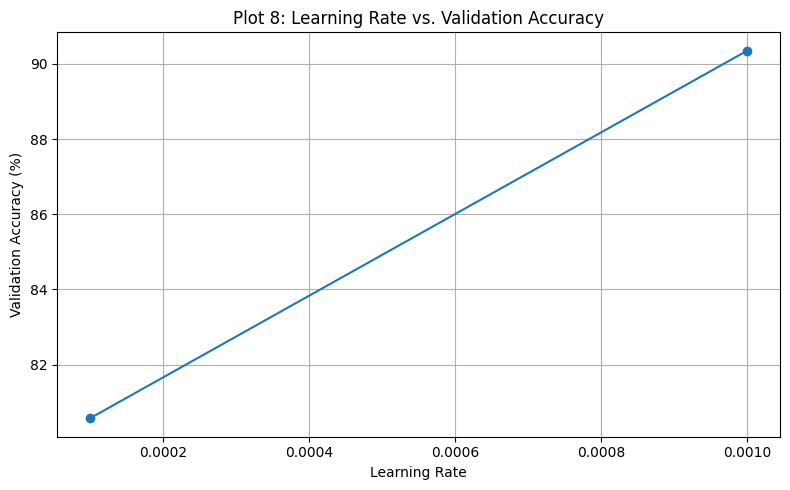

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_df["Learning Rate"],
    lr_df["Best Validation Accuracy (%)"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs. Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
batch_sizes = [16, 32, 64]

batch_results = []

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print("Batch Size:", batch_size)
    print("=" * 60)

    train_bs = train_dataset.unbatch().batch(batch_size)
    val_bs = val_dataset.unbatch().batch(batch_size)

    model = create_tuning_model(
        learning_rate=0.001,
        dropout_rate=0.0,
        optimizer_name="adam"
    )

    start_time = time.time()

    history = model.fit(
        train_bs,
        validation_data=val_bs,
        epochs=TUNING_EPOCHS,
        verbose=1
    )

    elapsed_time = time.time() - start_time

    best_val_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    best_epoch = (
        np.argmax(history.history["val_accuracy"]) + 1
    )

    batch_results.append({
        "Batch Size": batch_size,
        "Best Validation Accuracy (%)": best_val_accuracy,
        "Best Epoch": best_epoch,
        "Time (seconds)": elapsed_time
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    del history
    del model
    del train_bs
    del val_bs
    gc.collect()

batch_df = pd.DataFrame(batch_results)

print("\nBatch Size Results:")
display(batch_df)


Batch Size: 16
Epoch 1/3
    184/Unknown 22s 50ms/step - accuracy: 0.5627 - loss: 1.8153

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


184/184 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.7578 - loss: 1.0034 - val_accuracy: 0.8913 - val_loss: 0.4067
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9392 - loss: 0.2432 - val_accuracy: 0.8995 - val_loss: 0.3384
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.9718 - loss: 0.1408 - val_accuracy: 0.9049 - val_loss: 0.2978
Best Validation Accuracy: 90.49%

Batch Size: 32
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 171ms/step - accuracy: 0.6909 - loss: 1.2917 - val_accuracy: 0.8736 - val_loss: 0.4990
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 150ms/step - accuracy: 0.9270 - loss: 0.3072 - val_accuracy: 0.8899 - val_loss: 0.3752
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.9582 - loss: 0.1938 - val_accuracy: 0.9062 - val_loss: 0.3247
Best Validation Accuracy: 90.62%

Batch Size: 64
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - accuracy: 0.5941 - loss: 1.7188 - val_accuracy: 0.8465 - val_loss: 0.6604
Epoch 2/3
46/

,Batch Size,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,16,90.489131,3,58.811869
1,32,90.625000,3,68.616273
2,64,90.081519,3,70.545443


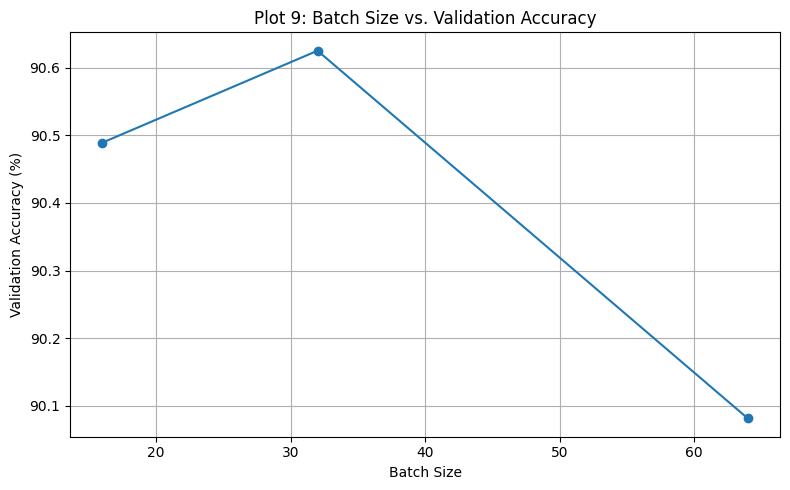

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    batch_df["Batch Size"],
    batch_df["Best Validation Accuracy (%)"],
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs. Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
dropout_rates = [0.0, 0.25, 0.5]

dropout_results = []

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print("Dropout Rate:", dropout_rate)
    print("=" * 60)

    model = create_tuning_model(
        learning_rate=0.001,
        dropout_rate=dropout_rate,
        optimizer_name="adam"
    )

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=TUNING_EPOCHS,
        verbose=1
    )

    elapsed_time = time.time() - start_time

    best_val_accuracy = max(
        history.history["val_accuracy"]
    ) * 100

    best_epoch = (
        np.argmax(history.history["val_accuracy"]) + 1
    )

    dropout_results.append({
        "Dropout Rate": dropout_rate,
        "Best Validation Accuracy (%)": best_val_accuracy,
        "Best Epoch": best_epoch,
        "Time (seconds)": elapsed_time
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    del history
    del model
    gc.collect()

dropout_df = pd.DataFrame(dropout_results)

print("\nDropout Results:")
display(dropout_df)


Dropout Rate: 0.0
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 111ms/step - accuracy: 0.7565 - loss: 1.0090 - val_accuracy: 0.8940 - val_loss: 0.4031
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.9433 - loss: 0.2360 - val_accuracy: 0.8981 - val_loss: 0.3289
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9681 - loss: 0.1407 - val_accuracy: 0.8913 - val_loss: 0.3281
Best Validation Accuracy: 89.81%

Dropout Rate: 0.25
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.7052 - loss: 1.1591 - val_accuracy: 0.8818 - val_loss: 0.4492
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9209 - loss: 0.3014 - val_accuracy: 0.9062 - val_loss: 0.3458
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9497 - loss: 0.1921 - val_accuracy: 0.8995 - val_loss: 0.3229
Best Validation Accuracy: 90.62%

Dropout Rate: 0.5
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 30s 88ms/step - accuracy: 0.6067 - loss: 1.4258 - val_accuracy

,Dropout Rate,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,0.00,89.809781,2,60.878376
1,0.25,90.625000,2,59.674658
2,0.50,89.945650,3,64.191078


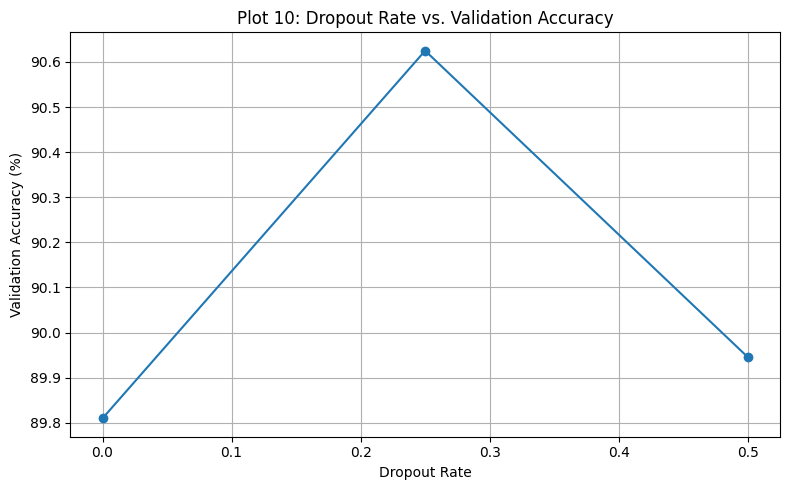

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_df["Dropout Rate"],
    dropout_df["Best Validation Accuracy (%)"],
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs. Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
print("=" * 80)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 80)

print("\nLearning Rate:")
display(lr_df)

print("\nBatch Size:")
display(batch_df)

print("\nDropout Rate:")
display(dropout_df)

HYPERPARAMETER TUNING SUMMARY

Learning Rate:


,Learning Rate,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,0.0010,90.353262,3,57.784095
1,0.0001,80.570650,3,56.810362



Batch Size:


,Batch Size,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,16,90.489131,3,58.811869
1,32,90.625000,3,68.616273
2,64,90.081519,3,70.545443



Dropout Rate:


,Dropout Rate,Best Validation Accuracy (%),Best Epoch,Time (seconds)
0,0.00,89.809781,2,60.878376
1,0.25,90.625000,2,59.674658
2,0.50,89.945650,3,64.191078


In [47]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc
import time

FINE_TUNE_EPOCHS = 3

In [48]:
def create_feature_extraction_model():
    tf.keras.backend.clear_session()
    gc.collect()

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze entire pretrained base
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [49]:
print("=" * 60)
print("CASE A: FEATURE EXTRACTION")
print("=" * 60)

feature_model = create_feature_extraction_model()

feature_history = feature_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

print("Best Feature Extraction Validation Accuracy:",
      max(feature_history.history["val_accuracy"]) * 100)

CASE A: FEATURE EXTRACTION
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 33s 111ms/step - accuracy: 0.7439 - loss: 1.0170 - val_accuracy: 0.8981 - val_loss: 0.3999
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.9450 - loss: 0.2407 - val_accuracy: 0.9090 - val_loss: 0.3264
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9742 - loss: 0.1407 - val_accuracy: 0.9062 - val_loss: 0.3114
Best Feature Extraction Validation Accuracy: 90.896737575531


In [50]:
def create_fine_tuning_model():

    tf.keras.backend.clear_session()
    gc.collect()

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # First freeze everything
    base_model.trainable = False

    # Unfreeze only the upper layers
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    # Small learning rate for fine-tuning
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [51]:
print("=" * 60)
print("CASE B: FINE-TUNING")
print("=" * 60)

fine_tune_model = create_fine_tuning_model()

fine_tune_history = fine_tune_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

print("Best Fine-Tuning Validation Accuracy:",
      max(fine_tune_history.history["val_accuracy"]) * 100)

CASE B: FINE-TUNING
Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.1349 - loss: 3.3853 - val_accuracy: 0.2731 - val_loss: 2.8121
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.4851 - loss: 2.3106 - val_accuracy: 0.6046 - val_loss: 1.8223
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.7184 - loss: 1.5687 - val_accuracy: 0.7677 - val_loss: 1.1801
Best Fine-Tuning Validation Accuracy: 76.7663061618805


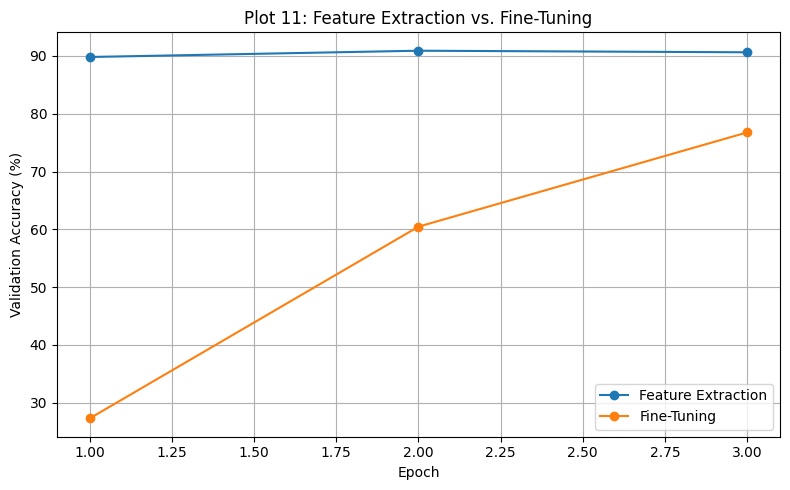

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    np.array(feature_history.history["val_accuracy"]) * 100,
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    np.array(fine_tune_history.history["val_accuracy"]) * 100,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs. Fine-Tuning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

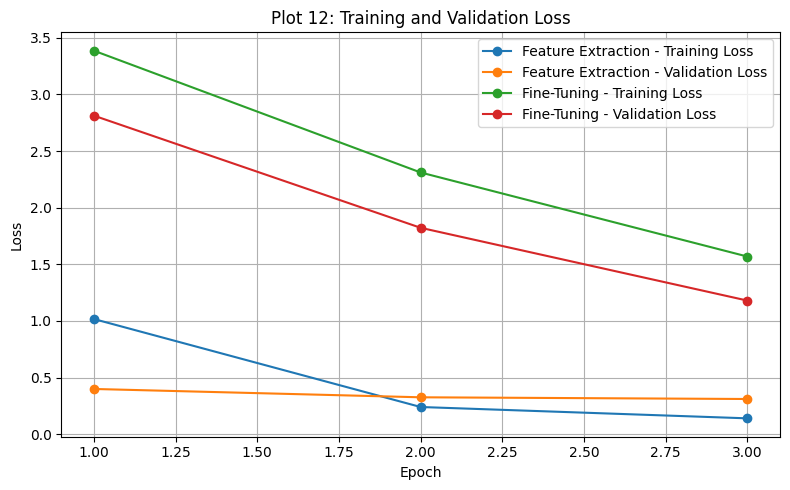

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    feature_history.history["loss"],
    marker="o",
    label="Feature Extraction - Training Loss"
)

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    feature_history.history["val_loss"],
    marker="o",
    label="Feature Extraction - Validation Loss"
)

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    fine_tune_history.history["loss"],
    marker="o",
    label="Fine-Tuning - Training Loss"
)

plt.plot(
    range(1, FINE_TUNE_EPOCHS + 1),
    fine_tune_history.history["val_loss"],
    marker="o",
    label="Fine-Tuning - Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
feature_best_acc = max(
    feature_history.history["val_accuracy"]
) * 100

fine_tune_best_acc = max(
    fine_tune_history.history["val_accuracy"]
) * 100

feature_final_loss = feature_history.history["loss"][-1]
fine_tune_final_loss = fine_tune_history.history["loss"][-1]

comparison = pd.DataFrame({
    "Method": [
        "Feature Extraction",
        "Fine-Tuning"
    ],
    "Best Validation Accuracy (%)": [
        feature_best_acc,
        fine_tune_best_acc
    ],
    "Final Training Loss": [
        feature_final_loss,
        fine_tune_final_loss
    ]
})

display(comparison)

,Method,Best Validation Accuracy (%),Final Training Loss
0,Feature Extraction,90.896738,0.140670
1,Fine-Tuning,76.766306,1.568698


In [ ]:
# import numpy as np
# import tensorflow as tf
# import pandas as pd
# import matplotlib.pyplot as plt
# import gc
# import time

# print("Preparing training data for 5-fold cross-validation...")

# x_train = []
# y_train = []

# for images, labels in train_dataset:
#     x_train.append(images.numpy())
#     y_train.append(labels.numpy())

# x_train = np.concatenate(x_train, axis=0)
# y_train = np.concatenate(y_train, axis=0)

# print("Training images:", x_train.shape)
# print("Training labels:", y_train.shape)
# print("Number of samples:", len(x_train))

Preparing training data for 5-fold cross-validation...


In [1]:
from sklearn.model_selection import KFold
import numpy as np
import tensorflow as tf
import gc

# Number of training samples
NUM_SAMPLES = 2944

indices = np.arange(NUM_SAMPLES)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation prepared")
print("Total samples:", NUM_SAMPLES)

/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

5-Fold Cross-Validation prepared
Total samples: 2944


In [2]:
def make_fold_dataset(dataset, selected_indices, batch_size=32):

    selected_indices = tf.constant(
        selected_indices,
        dtype=tf.int64
    )

    dataset = dataset.unbatch()
    dataset = dataset.enumerate()

    dataset = dataset.filter(
        lambda i, data: tf.reduce_any(tf.equal(i, selected_indices))
    )

    dataset = dataset.map(
        lambda i, data: data,
        num_parallel_calls=1
    )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(1)

    return dataset


print("Fold dataset function created successfully.")


Fold dataset function created successfully.


In [3]:
# Create the 5-fold train/validation index splits

fold_splits = []

for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
    fold_splits.append((train_idx, val_idx))

    print(
        f"Fold {fold}: "
        f"Training = {len(train_idx)}, "
        f"Validation = {len(val_idx)}"
    )

print("\nAll 5 folds created successfully.")

Fold 1: Training = 2355, Validation = 589
Fold 2: Training = 2355, Validation = 589
Fold 3: Training = 2355, Validation = 589
Fold 4: Training = 2355, Validation = 589
Fold 5: Training = 2356, Validation = 588

All 5 folds created successfully.


In [5]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import gc

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 37

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # MobileNetV2 preprocessing: [0,255] -> [-1,1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label


# Load dataset
(train_raw, test_raw), info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Shuffle once and create 80/20 train-validation split
train_raw = train_raw.shuffle(
    buffer_size=3680,
    seed=42,
    reshuffle_each_iteration=False
)

train_raw = train_raw.take(2944)
val_raw = tfds.load(
    "oxford_iiit_pet",
    split="train",
    as_supervised=True
).shuffle(
    buffer_size=3680,
    seed=42,
    reshuffle_each_iteration=False
).skip(2944)


# Preprocess and batch
train_dataset = (
    train_raw
    .map(preprocess, num_parallel_calls=1)
    .batch(BATCH_SIZE)
    .prefetch(1)
)

val_dataset = (
    val_raw
    .map(preprocess, num_parallel_calls=1)
    .batch(BATCH_SIZE)
    .prefetch(1)
)

test_dataset = (
    test_raw
    .map(preprocess, num_parallel_calls=1)
    .batch(BATCH_SIZE)
    .prefetch(1)
)

print("Datasets recreated successfully.")
print("Training samples: 2944")
print("Validation samples: 736")
print("Test samples: 3669")
print("Number of classes:", NUM_CLASSES)

Datasets recreated successfully.
Training samples: 2944
Validation samples: 736
Test samples: 3669
Number of classes: 37


In [7]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print(
        "Pixel range:",
        tf.reduce_min(images).numpy(),
        "to",
        tf.reduce_max(images).numpy()
    )

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Pixel range: -1.0 to 1.0


In [8]:
# Test Fold 1 dataset creation

train_idx, val_idx = fold_splits[0]

fold_train = make_fold_dataset(
    train_dataset,
    train_idx,
    batch_size=32
)

fold_val = make_fold_dataset(
    train_dataset,
    val_idx,
    batch_size=32
)

print("Fold 1 datasets created.")

Fold 1 datasets created.


In [9]:
print("train_dataset:", train_dataset)
print("fold_splits:", len(fold_splits))
print("Fold 1 train samples:", len(fold_splits[0][0]))
print("Fold 1 validation samples:", len(fold_splits[0][1]))

train_dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
fold_splits: 5
Fold 1 train samples: 2355
Fold 1 validation samples: 589


In [11]:
def create_cv_model(learning_rate, dropout, optimizer_name):

    tf.keras.backend.clear_session()
    gc.collect()

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained MobileNetV2
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    if optimizer_name.lower() == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer_name.lower() == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("create_cv_model function recreated successfully.")

create_cv_model function recreated successfully.


In [12]:
tf.keras.backend.clear_session()
gc.collect()

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

print("Model created successfully.")

Model created successfully.


In [14]:
# Train Fold 1 - RAM safe

tf.keras.backend.clear_session()
gc.collect()

fold_train = make_fold_dataset(
    train_dataset,
    fold_splits[0][0],
    batch_size=16
)

fold_val = make_fold_dataset(
    train_dataset,
    fold_splits[0][1],
    batch_size=16
)

history_fold1 = model.fit(
    fold_train,
    validation_data=fold_val,
    epochs=3,
    verbose=1
)

print("Fold 1 training completed successfully.")

Epoch 1/3
    148/Unknown 50s 121ms/step - accuracy: 0.5185 - loss: 1.9610

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


148/148 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - accuracy: 0.7227 - loss: 1.1223 - val_accuracy: 0.8846 - val_loss: 0.4779
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 63s 373ms/step - accuracy: 0.9499 - loss: 0.2519 - val_accuracy: 0.8930 - val_loss: 0.3819
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 142ms/step - accuracy: 0.9745 - loss: 0.1444 - val_accuracy: 0.8964 - val_loss: 0.3468
Fold 1 training completed successfully.


In [15]:
# Evaluate Fold 1

fold1_loss, fold1_accuracy = model.evaluate(
    fold_val,
    verbose=1
)

print(f"Fold 1 Validation Accuracy: {fold1_accuracy * 100:.2f}%")
print(f"Fold 1 Validation Loss: {fold1_loss:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.8964 - loss: 0.3468
Fold 1 Validation Accuracy: 89.64%
Fold 1 Validation Loss: 0.3468


In [16]:
# Clear Fold 1 model and datasets from memory

del model
del fold_train
del fold_val

tf.keras.backend.clear_session()
gc.collect()

print("Fold 1 cleared from memory.")

Fold 1 cleared from memory.


In [17]:
# Fold 2

fold_train = make_fold_dataset(
    train_dataset,
    fold_splits[1][0],
    batch_size=16
)

fold_val = make_fold_dataset(
    train_dataset,
    fold_splits[1][1],
    batch_size=16
)

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_fold2 = model.fit(
    fold_train,
    validation_data=fold_val,
    epochs=3,
    verbose=1
)

fold2_loss, fold2_accuracy = model.evaluate(
    fold_val,
    verbose=1
)

print(f"Fold 2 Validation Accuracy: {fold2_accuracy * 100:.2f}%")
print(f"Fold 2 Validation Loss: {fold2_loss:.4f}")

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 213ms/step - accuracy: 0.7159 - loss: 1.1779 - val_accuracy: 0.8812 - val_loss: 0.4303
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 111ms/step - accuracy: 0.9423 - loss: 0.2632 - val_accuracy: 0.9049 - val_loss: 0.3284
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9732 - loss: 0.1499 - val_accuracy: 0.9032 - val_loss: 0.2961
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.9032 - loss: 0.2961
Fold 2 Validation Accuracy: 90.32%
Fold 2 Validation Loss: 0.2961


In [18]:
# Save Fold 2 result

fold_accuracies = [fold1_accuracy, fold2_accuracy]
fold_losses = [fold1_loss, fold2_loss]

print("Fold accuracies saved:")
print(fold_accuracies)

Fold accuracies saved:
[0.8964346647262573, 0.9032257795333862]


In [19]:
# Clear Fold 2 from memory

del model
del fold_train
del fold_val

tf.keras.backend.clear_session()
gc.collect()

print("Fold 2 cleared from memory.")

Fold 2 cleared from memory.


In [20]:
# Fold 3

fold_train = make_fold_dataset(
    train_dataset,
    fold_splits[2][0],
    batch_size=16
)

fold_val = make_fold_dataset(
    train_dataset,
    fold_splits[2][1],
    batch_size=16
)

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_fold3 = model.fit(
    fold_train,
    validation_data=fold_val,
    epochs=3,
    verbose=1
)

fold3_loss, fold3_accuracy = model.evaluate(
    fold_val,
    verbose=1
)

print(f"Fold 3 Validation Accuracy: {fold3_accuracy * 100:.2f}%")
print(f"Fold 3 Validation Loss: {fold3_loss:.4f}")

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 211ms/step - accuracy: 0.7227 - loss: 1.1403 - val_accuracy: 0.9015 - val_loss: 0.4158
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 137ms/step - accuracy: 0.9401 - loss: 0.2647 - val_accuracy: 0.8998 - val_loss: 0.3189
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 85s 398ms/step - accuracy: 0.9711 - loss: 0.1526 - val_accuracy: 0.9049 - val_loss: 0.2843
37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 86ms/step - accuracy: 0.9049 - loss: 0.2843
Fold 3 Validation Accuracy: 90.49%
Fold 3 Validation Loss: 0.2843


In [21]:
# Save Fold 3 result

fold_accuracies.append(fold3_accuracy)
fold_losses.append(fold3_loss)

print("Fold 3 result saved.")
print("Accuracies so far:", [round(x * 100, 2) for x in fold_accuracies])

Fold 3 result saved.
Accuracies so far: [89.64, 90.32, 90.49]


In [22]:
# Clear Fold 3 from memory

del model
del fold_train
del fold_val
del history_fold3

tf.keras.backend.clear_session()
gc.collect()

print("Fold 3 cleared from memory.")

Fold 3 cleared from memory.


In [23]:
# Fold 4

fold_train = make_fold_dataset(
    train_dataset,
    fold_splits[3][0],
    batch_size=16
)

fold_val = make_fold_dataset(
    train_dataset,
    fold_splits[3][1],
    batch_size=16
)

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_fold4 = model.fit(
    fold_train,
    validation_data=fold_val,
    epochs=3,
    verbose=1
)

fold4_loss, fold4_accuracy = model.evaluate(
    fold_val,
    verbose=1
)

print(f"Fold 4 Validation Accuracy: {fold4_accuracy * 100:.2f}%")
print(f"Fold 4 Validation Loss: {fold4_loss:.4f}")

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 52s 221ms/step - accuracy: 0.7159 - loss: 1.1722 - val_accuracy: 0.8676 - val_loss: 0.4556
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 123ms/step - accuracy: 0.9346 - loss: 0.2689 - val_accuracy: 0.8913 - val_loss: 0.3307
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 43s 236ms/step - accuracy: 0.9720 - loss: 0.1547 - val_accuracy: 0.8998 - val_loss: 0.2836
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.8998 - loss: 0.2836
Fold 4 Validation Accuracy: 89.98%
Fold 4 Validation Loss: 0.2836


In [24]:
# Save Fold 4 result

fold_accuracies.append(fold4_accuracy)
fold_losses.append(fold4_loss)

print("Fold 4 result saved.")
print("Accuracies so far:", [round(x * 100, 2) for x in fold_accuracies])

Fold 4 result saved.
Accuracies so far: [89.64, 90.32, 90.49, 89.98]


In [25]:
# Clear Fold 4 from memory

del model
del fold_train
del fold_val
del history_fold4

tf.keras.backend.clear_session()
gc.collect()

print("Fold 4 cleared from memory.")

Fold 4 cleared from memory.


In [26]:
# Fold 5

fold_train = make_fold_dataset(
    train_dataset,
    fold_splits[4][0],
    batch_size=16
)

fold_val = make_fold_dataset(
    train_dataset,
    fold_splits[4][1],
    batch_size=16
)

model = create_cv_model(
    learning_rate=0.001,
    dropout=0.0,
    optimizer_name="adam"
)

history_fold5 = model.fit(
    fold_train,
    validation_data=fold_val,
    epochs=3,
    verbose=1
)

fold5_loss, fold5_accuracy = model.evaluate(
    fold_val,
    verbose=1
)

print(f"Fold 5 Validation Accuracy: {fold5_accuracy * 100:.2f}%")
print(f"Fold 5 Validation Loss: {fold5_loss:.4f}")

Epoch 1/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 69s 330ms/step - accuracy: 0.7156 - loss: 1.1706 - val_accuracy: 0.8588 - val_loss: 0.4862
Epoch 2/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 113ms/step - accuracy: 0.9503 - loss: 0.2500 - val_accuracy: 0.8827 - val_loss: 0.3793
Epoch 3/3
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 108ms/step - accuracy: 0.9762 - loss: 0.1421 - val_accuracy: 0.8861 - val_loss: 0.3422
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.8861 - loss: 0.3422
Fold 5 Validation Accuracy: 88.61%
Fold 5 Validation Loss: 0.3422


In [27]:
# Save Fold 5 result

fold_accuracies.append(fold5_accuracy)
fold_losses.append(fold5_loss)

print("Fold 5 result saved.")
print("All 5 fold accuracies:",
      [round(x * 100, 2) for x in fold_accuracies])

Fold 5 result saved.
All 5 fold accuracies: [89.64, 90.32, 90.49, 89.98, 88.61]


In [28]:
# Clear Fold 5 from memory

del model
del fold_train
del fold_val
del history_fold5

tf.keras.backend.clear_session()
gc.collect()

print("Fold 5 cleared from memory.")

Fold 5 cleared from memory.


In [29]:
# C1 - 5-Fold Cross-Validation Result

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print("=" * 60)
print("C1 - 5-Fold Cross-Validation")
print("=" * 60)

for i, acc in enumerate(fold_accuracies, 1):
    print(f"Fold {i}: {acc * 100:.2f}%")

print("-" * 60)
print(f"Mean Accuracy: {mean_accuracy * 100:.2f}%")
print(f"Standard Deviation: {std_accuracy * 100:.2f}%")
print(f"Mean ± SD: {mean_accuracy * 100:.2f}% ± {std_accuracy * 100:.2f}%")

C1 - 5-Fold Cross-Validation
Fold 1: 89.64%
Fold 2: 90.32%
Fold 3: 90.49%
Fold 4: 89.98%
Fold 5: 88.61%
------------------------------------------------------------
Mean Accuracy: 89.81%
Standard Deviation: 0.67%
Mean ± SD: 89.81% ± 0.67%
